giant done n=100
giant done n=200
giant done n=400
connectivity done n=50
connectivity done n=100


KeyboardInterrupt: 

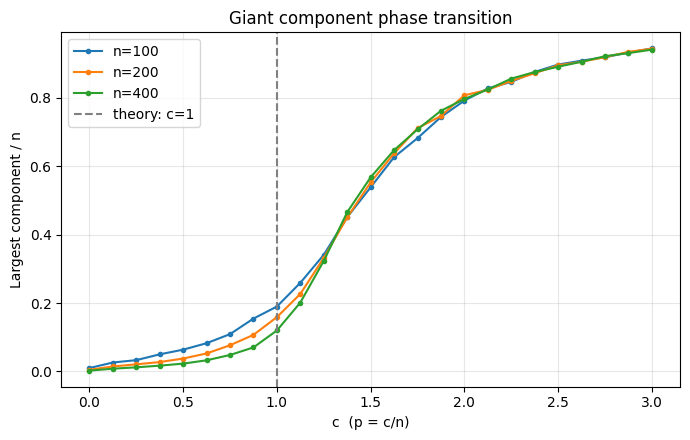

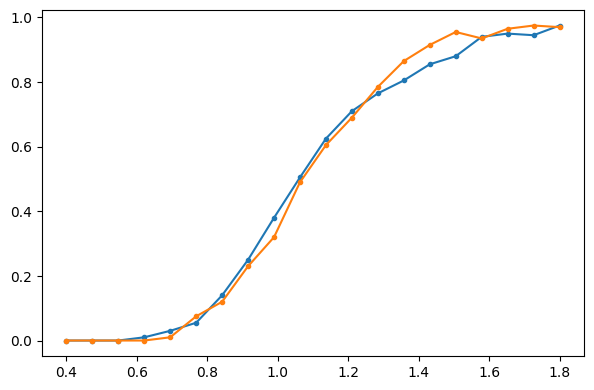

In [1]:
"""
Random Graphs G(n, p): DFS + Monte Carlo simulation
- Experiment 1: Giant component ka phase transition (p = c/n, threshold c = 1)
- Experiment 2: Connectivity ka phase transition (threshold p = ln(n)/n)

Run: python random_graphs.py
Requirements: pip install numpy matplotlib
"""
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def random_graph(n, p):
    """G(n,p) banao: har edge independently probability p se. Adjacency list return."""
    adj = [[] for _ in range(n)]
    # upper triangle ke saare pairs ke liye ek saath random numbers
    iu, ju = np.triu_indices(n, k=1)
    mask = rng.random(len(iu)) < p
    for u, v in zip(iu[mask], ju[mask]):
        adj[u].append(v)
        adj[v].append(u)
    return adj


def component_sizes(adj):
    """Iterative DFS se saare connected components ke sizes nikalo."""
    n = len(adj)
    visited = [False] * n
    sizes = []
    for s in range(n):
        if visited[s]:
            continue
        stack = [s]
        visited[s] = True
        size = 0
        while stack:
            u = stack.pop()
            size += 1
            for v in adj[u]:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        sizes.append(size)
    return sizes


def giant_fraction(n, p):
    """Sabse bade component ka size / n"""
    return max(component_sizes(random_graph(n, p))) / n


def is_connected(n, p):
    return len(component_sizes(random_graph(n, p))) == 1


def experiment_giant(ns=(100, 200, 400), trials=100):
    """p = c/n ke liye c ko 0 se 3 tak badhao. c=1 ke paas giant component banta hai."""
    cs = np.linspace(0, 3, 25)
    plt.figure(figsize=(7, 4.5))
    for n in ns:
        y = [np.mean([giant_fraction(n, c / n) for _ in range(trials)]) for c in cs]
        plt.plot(cs, y, marker="o", ms=3, label=f"n={n}")
        print(f"giant done n={n}")
    plt.axvline(1, color="gray", ls="--", label="theory: c=1")
    plt.xlabel("c  (p = c/n)")
    plt.ylabel("Largest component / n")
    plt.title("Giant component phase transition")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("giant_component.png", dpi=150)


def experiment_connectivity(ns=(50, 100, 200), trials=200):
    """p = c*ln(n)/n ke liye c ko 0.4 se 1.8 tak. c=1 ke paas graph connected hota hai."""
    cs = np.linspace(0.4, 1.8, 20)
    plt.figure(figsize=(7, 4.5))
    for n in ns:
        y = [
            np.mean([is_connected(n, min(1.0, c * np.log(n) / n)) for _ in range(trials)])
            for c in cs
        ]
        plt.plot(cs, y, marker="o", ms=3, label=f"n={n}")
        print(f"connectivity done n={n}")
    plt.axvline(1, color="gray", ls="--", label="theory: c=1")
    plt.xlabel("c  (p = c ln(n) / n)")
    plt.ylabel("P(graph connected)")
    plt.title("Connectivity phase transition")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("connectivity.png", dpi=150)


if __name__ == "__main__":
    experiment_giant()
    experiment_connectivity()
    print("Done! giant_component.png aur connectivity.png save ho gaye.")
    plt.show()
